## Project Overview
This project analyses Premier League match data from 2015/16 to 2024/25 to explore goal trends, team performance and home vs away advantage.

Methodology:
- Combined 10 seasons of match-level data
- Engineered performance metrics (goal difference, win indicators)
- Analysed league-wide trends and team benchmarking

## Import Libraries

In [2]:
# Import the Google Drive module from Colab
# This allows us to access files stored in Google Drive
from google.colab import drive

# Mount Google Drive to the Colab environment
# This creates a connection between Colab and your Drive storage
drive.mount('/content/drive')

Mounted at /content/drive


## Data Ingestion (Load & Combine Season Data)

In [3]:
# Define the file path to the Data folder inside Google Drive
# Make sure the folder name matches exactly (including spaces and capital letters)
data_path = "/content/drive/MyDrive/Project - Premier League/Data"

In [4]:
# Import os module to interact with the file system
import os

# List all files inside the Data folder to verify correct connection
os.listdir(data_path)

['E0_1516.csv',
 'E0_1617.csv',
 'E0_1718.csv',
 'E0_1819.csv',
 'E0_1920.csv',
 'E0_2021.csv',
 'E0_2122.csv',
 'E0_2223.csv',
 'E0_2324.csv',
 'E0_2425.csv']

In [5]:
import pandas as pd
import os

# Define path
data_path = "/content/drive/MyDrive/Project - Premier League/Data"

# Get all CSV files
all_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

dfs = []

for file in all_files:
    df = pd.read_csv(os.path.join(data_path, file))

    # Extract season from filename
    season = file.replace("E0_", "").replace(".csv", "")
    df["season"] = season

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

combined_df.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,E0,08/08/2015,Bournemouth,Aston Villa,0,1,A,0,0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,08/08/2015,Chelsea,Swansea,2,2,D,2,1,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,08/08/2015,Everton,Watford,2,2,D,0,1,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,08/08/2015,Leicester,Sunderland,4,2,H,3,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,08/08/2015,Man United,Tottenham,1,0,H,1,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
combined_df.shape

(3800, 154)

## Data Preparation

In [7]:
# Select only relevant columns
combined_df = combined_df[[
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
    "season"
]]

combined_df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,season
0,08/08/2015,Bournemouth,Aston Villa,0,1,A,1516
1,08/08/2015,Chelsea,Swansea,2,2,D,1516
2,08/08/2015,Everton,Watford,2,2,D,1516
3,08/08/2015,Leicester,Sunderland,4,2,H,1516
4,08/08/2015,Man United,Tottenham,1,0,H,1516


In [8]:
combined_df.shape

(3800, 7)

## Feature Engineering

In [9]:
# Create total goals column (home goals + away goals)
combined_df["total_goals"] = combined_df["FTHG"] + combined_df["FTAG"]

combined_df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,season,total_goals
0,08/08/2015,Bournemouth,Aston Villa,0,1,A,1516,1
1,08/08/2015,Chelsea,Swansea,2,2,D,1516,4
2,08/08/2015,Everton,Watford,2,2,D,1516,4
3,08/08/2015,Leicester,Sunderland,4,2,H,1516,6
4,08/08/2015,Man United,Tottenham,1,0,H,1516,1


In [10]:
combined_df[["FTHG", "FTAG", "total_goals"]].head()

,FTHG,FTAG,total_goals
0,0,1,1
1,2,2,4
2,2,2,4
3,4,2,6
4,1,0,1


In [11]:
# Create home win indicator (1 if home team wins, 0 otherwise)
combined_df["home_win"] = (combined_df["FTR"] == "H").astype(int)

combined_df[["FTR", "home_win"]].head()

,FTR,home_win
0,A,0
1,D,0
2,D,0
3,H,1
4,H,1


In [12]:
# Create away win indicator
combined_df["away_win"] = (combined_df["FTR"] == "A").astype(int)

In [13]:
# Create absolute goal difference (how far apart scores were)
combined_df["abs_goal_diff"] = abs(combined_df["FTHG"] - combined_df["FTAG"])

combined_df[["FTHG", "FTAG", "abs_goal_diff"]].head()

,FTHG,FTAG,abs_goal_diff
0,0,1,1
1,2,2,0
2,2,2,0
3,4,2,2
4,1,0,1


In [14]:
# Filter matches involving Liverpool
liverpool_df = combined_df[
    (combined_df["HomeTeam"] == "Liverpool") |
    (combined_df["AwayTeam"] == "Liverpool")
].copy()

In [15]:
# Calculate Liverpool goal difference (from Liverpool's perspective)
liverpool_df["liverpool_goal_diff"] = liverpool_df.apply(
    lambda row: row["FTHG"] - row["FTAG"] if row["HomeTeam"] == "Liverpool"
    else row["FTAG"] - row["FTHG"],
    axis=1
)

liverpool_df[["HomeTeam", "AwayTeam", "FTHG", "FTAG", "liverpool_goal_diff"]].head()

,HomeTeam,AwayTeam,FTHG,FTAG,liverpool_goal_diff
8,Stoke,Liverpool,0,1,1
19,Liverpool,Bournemouth,1,0,1
29,Arsenal,Liverpool,0,0,0
33,Liverpool,West Ham,0,3,-3
43,Man United,Liverpool,3,1,-2


In [16]:
# Net goal difference (home team perspective)
combined_df["goal_diff"] = combined_df["FTHG"] - combined_df["FTAG"]

combined_df[["FTHG", "FTAG", "goal_diff"]].head()

,FTHG,FTAG,goal_diff
0,0,1,-1
1,2,2,0
2,2,2,0
3,4,2,2
4,1,0,1


## Exploratory Analysis

In [17]:
# Calculate average goals per match per season
avg_goals_per_season = combined_df.groupby("season")["total_goals"].mean()

avg_goals_per_season

,total_goals
season,
1516,2.700000
1617,2.800000
1718,2.678947
1819,2.821053
1920,2.721053
2021,2.694737
2122,2.818421
2223,2.852632
2324,3.278947


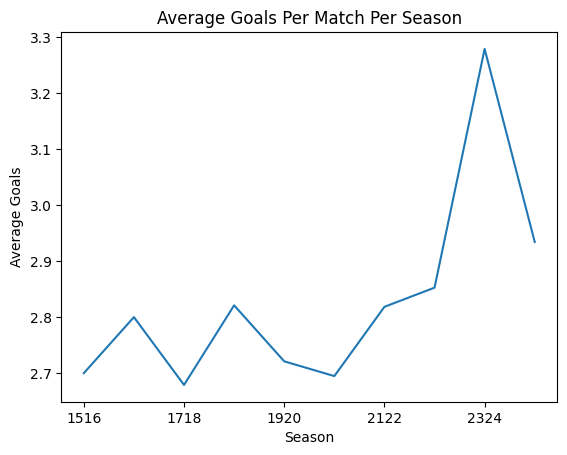

In [18]:
import matplotlib.pyplot as plt

# Create simple line chart for average goals per season
plt.figure()
avg_goals_per_season.plot()

plt.title("Average Goals Per Match Per Season")
plt.xlabel("Season")
plt.ylabel("Average Goals")

plt.show()

Insight: Average goals per match peaked in 2023/24, indicating a recent increase in attacking output.

In [19]:
# Calculate home win rate per season
home_win_rate = combined_df.groupby("season")["home_win"].mean()

home_win_rate

,home_win
season,
1516,0.413158
1617,0.492105
1718,0.455263
1819,0.476316
1920,0.452632
2021,0.378947
2122,0.428947
2223,0.484211
2324,0.460526


In [20]:
# Calculate away win rate
away_win_rate = combined_df.groupby("season")["away_win"].mean()

away_win_rate

,away_win
season,
1516,0.305263
1617,0.286842
1718,0.284211
1819,0.336842
1920,0.305263
2021,0.402632
2122,0.339474
2223,0.286842
2324,0.323684


Insight: Home win rate dropped sharply in 2020/21 while away win rate rose, suggesting reduced home advantage during COVID.

In [21]:
# Calculate average absolute goal difference per season
competitiveness = combined_df.groupby("season")["abs_goal_diff"].mean()

competitiveness

,abs_goal_diff
season,
1516,1.289474
1617,1.505263
1718,1.426316
1819,1.531579
1920,1.447368
2021,1.426316
2122,1.513158
2223,1.457895
2324,1.584211


In [22]:
# Liverpool average goal difference per season
liverpool_gd_per_season = liverpool_df.groupby("season")["liverpool_goal_diff"].mean()

liverpool_gd_per_season

,liverpool_goal_diff
season,
1516,0.342105
1617,0.947368
1718,1.210526
1819,1.763158
1920,1.368421
2021,0.684211
2122,1.789474
2223,0.736842
2324,1.184211


In [23]:
# League average net goal difference per season
league_net_gd = combined_df.groupby("season")["goal_diff"].mean()

league_net_gd

,goal_diff
season,
1516,0.284211
1617,0.394737
1718,0.384211
1819,0.315789
1920,0.310526
2021,0.010526
2122,0.207895
2223,0.415789
2324,0.321053


In [24]:
# Combine Liverpool and League goal difference into one comparison table
comparison_df = pd.DataFrame({
    "Liverpool_GD": liverpool_gd_per_season,
    "League_Home_GD": league_net_gd
})

comparison_df

,Liverpool_GD,League_Home_GD
season,,
1516,0.342105,0.284211
1617,0.947368,0.394737
1718,1.210526,0.384211
1819,1.763158,0.315789
1920,1.368421,0.310526
2021,0.684211,0.010526
2122,1.789474,0.207895
2223,0.736842,0.415789
2324,1.184211,0.321053


In [25]:
# Calculate performance gap vs league
comparison_df["Performance_Gap"] = (
    comparison_df["Liverpool_GD"] - comparison_df["League_Home_GD"]
)

comparison_df

,Liverpool_GD,League_Home_GD,Performance_Gap
season,,,
1516,0.342105,0.284211,0.057895
1617,0.947368,0.394737,0.552632
1718,1.210526,0.384211,0.826316
1819,1.763158,0.315789,1.447368
1920,1.368421,0.310526,1.057895
2021,0.684211,0.010526,0.673684
2122,1.789474,0.207895,1.581579
2223,0.736842,0.415789,0.321053
2324,1.184211,0.321053,0.863158


Insight: Liverpool consistently outperformed the league baseline, with the largest performance gaps in 2018/19 and 2021/22.

## Key Findings
- Average goals per match increased in recent seasons, peaking in 2023/24.
- Home advantage weakened significantly during the 2020/21 COVID season.
- Match competitiveness remained broadly stable, with slightly larger margins in 2023/24.
- Liverpool consistently outperformed league-average dominance, particularly in 2018/19 and 2021/22.